In [ ]:
# IMPORTS
# All libraries we need for the entire EDA notebook
# =============================================================

import pandas as pd               # Data manipulation
import numpy as np                # Numerical operations
import matplotlib.pyplot as plt   # Base plotting library
import seaborn as sns             # prettier plots
import warnings

Matplotlib is building the font cache; this may take a moment.


In [5]:
# LOAD DATA
# =============================================================

df = pd.read_csv("../data/raw/telco_churn.csv")

print(f"Dataset shape: {df.shape}")
# shape gives (rows, columns) — first thing to always check

Dataset shape: (7043, 21)


In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
# =============================================================
# DATA TYPES
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [12]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.5%


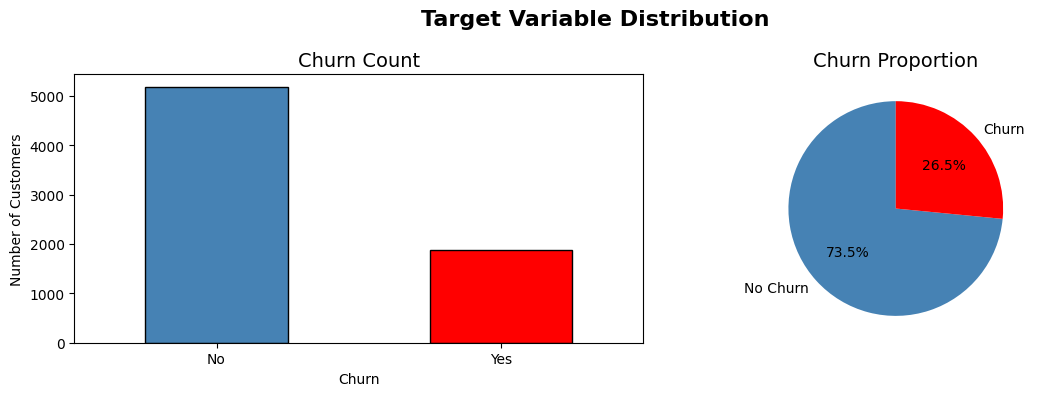

In [28]:
# =============================================================
# TARGET VARIABLE — CHURN DISTRIBUTION
# This is the most important chart in the entire notebook.
# It tells us: is the dataset balanced or imbalanced?
#
# Imbalanced = one class (No churn) is much more common than other (Churn)
# If 95% of customers don't churn, a model that always says "No" gets 95% accuracy
# but is completely useless — this is why we need to know this early
# =============================================================

churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100  
# normalize=True gives proportions, multiply by 100 for percentages

print(churn_counts)
print(f"\nChurn Rate: {churn_pct['Yes']:.1f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
churn_counts.plot(kind="bar", ax=axes[0], color=["steelblue", "red"], edgecolor="black")
axes[0].set_title("Churn Count", fontsize=14)
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
axes[1].pie(churn_counts, labels=["No Churn", "Churn"], autopct="%1.1f%%",
            colors=["steelblue", "red"], startangle=90)
axes[1].set_title("Churn Proportion", fontsize=14)

plt.suptitle("Target Variable Distribution", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


<Axes: xlabel='tenure', ylabel='Count'>

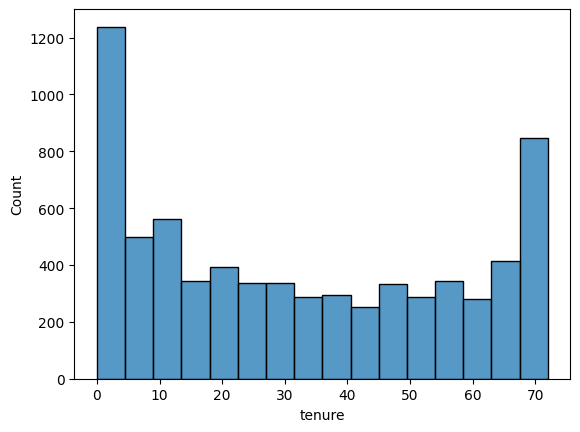

In [ ]:
sns.histplot(df["tenure"])
#number of months customer has been with the company

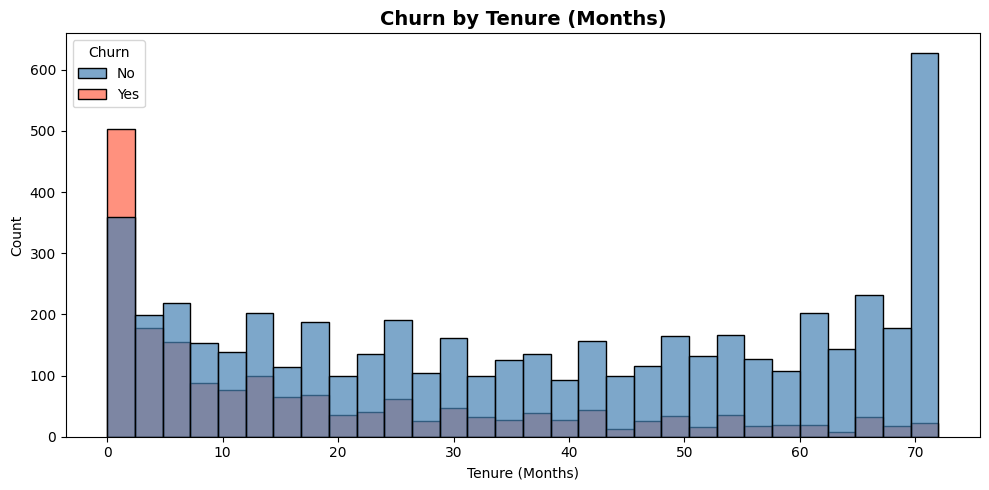

<Axes: xlabel='Churn', ylabel='tenure'>

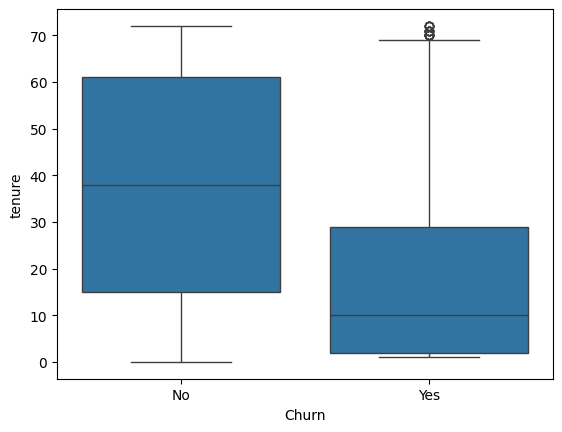

In [ ]:
# =============================================================
# CHURN BY TENURE
# Tenure = how many months the customer has been with the company
# Hypothesis: newer customers churn more (they haven't committed yet)
# =============================================================

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="tenure", hue="Churn",
             bins=30, palette={"No": "steelblue", "Yes": "tomato"},
             alpha=0.7)

plt.title("Churn by Tenure (Months)", fontsize=14, fontweight="bold")
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

sns.boxplot(x="Churn", y="tenure", data=df)
#outliers in tenure - customers

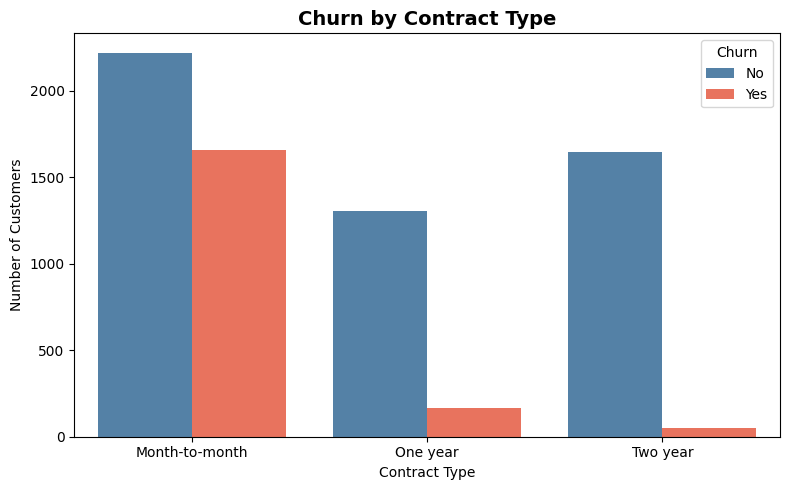

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


In [31]:
# =============================================================
# CHURN BY CONTRACT TYPE
# Contract type is usually the strongest predictor of churn.
# Month-to-month customers can leave anytime — are they churning more?
# =============================================================

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn",
              palette={"No": "steelblue", "Yes": "tomato"})

plt.title("Churn by Contract Type", fontsize=14, fontweight="bold")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

# Print the churn rate per contract type for clarity
print(df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack() * 100)

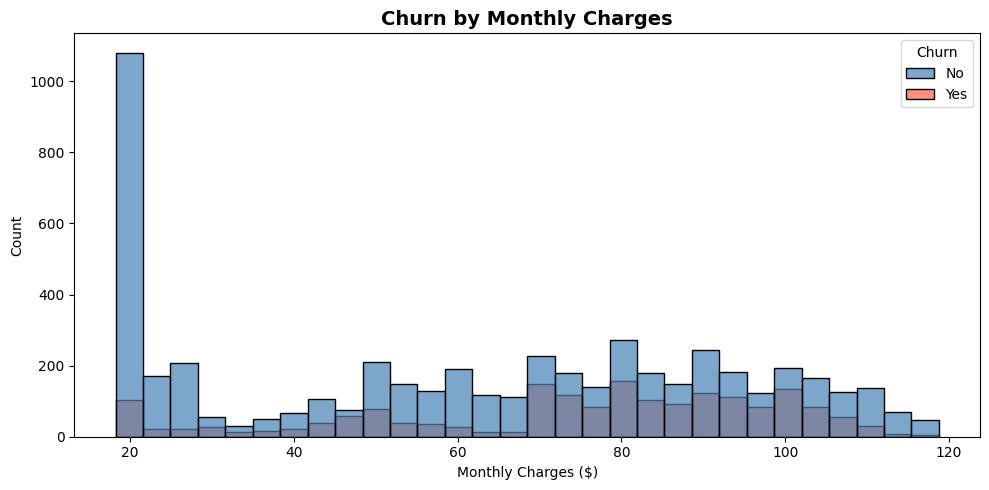

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


In [32]:
# =============================================================
# CHURN BY MONTHLY CHARGES
# Are high-paying customers more likely to churn?
# This also tells us the revenue at risk
# =============================================================

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="MonthlyCharges", hue="Churn",
             bins=30, palette={"No": "steelblue", "Yes": "tomato"},
             alpha=0.7)

plt.title("Churn by Monthly Charges", fontsize=14, fontweight="bold")
plt.xlabel("Monthly Charges ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Average monthly charge for churners vs non-churners
print(df.groupby("Churn")["MonthlyCharges"].mean().round(2))

In [33]:
# =============================================================
# REVENUE AT RISK
# This is the BUSINESS framing of the problem.
# How much monthly revenue could we lose if churners leave?
# This number justifies the entire retention budget.
# =============================================================

total_monthly_revenue = df["MonthlyCharges"].sum()

churner_revenue = df[df["Churn"] == "Yes"]["MonthlyCharges"].sum()

print(f"Total Monthly Revenue:        ${total_monthly_revenue:,.2f}")
print(f"Monthly Revenue at Risk:      ${churner_revenue:,.2f}")
print(f"% of Revenue at Risk:         {(churner_revenue/total_monthly_revenue)*100:.1f}%")

Total Monthly Revenue:        $456,116.60
Monthly Revenue at Risk:      $139,130.85
% of Revenue at Risk:         30.5%


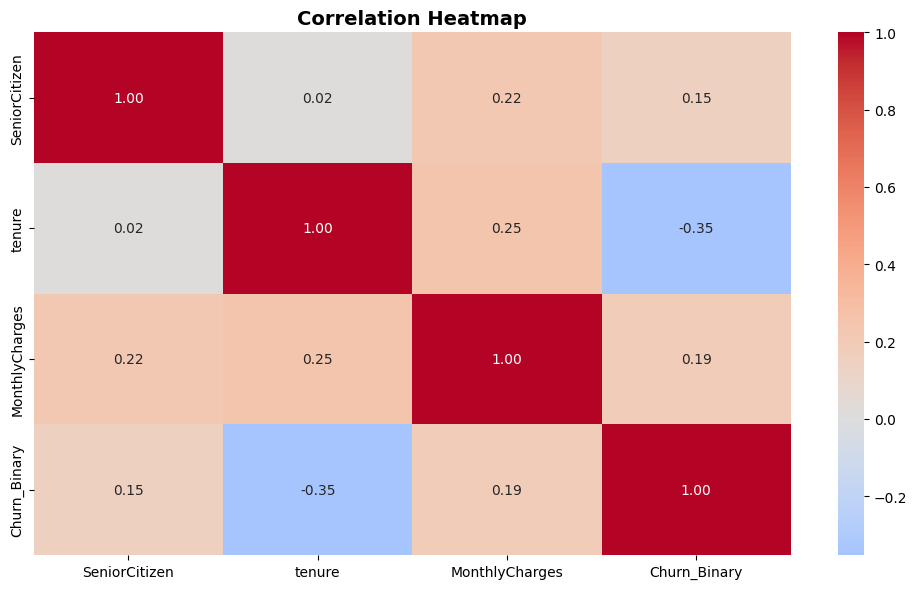

<Axes: >

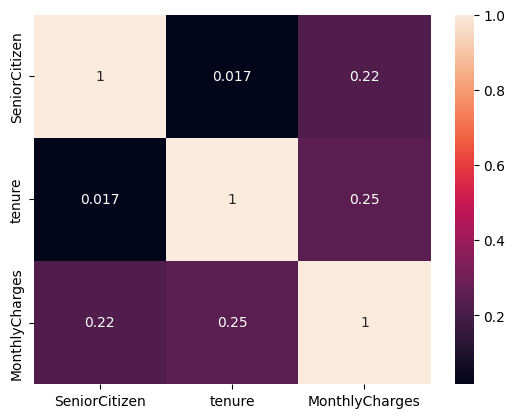

In [44]:
# =============================================================
# CORRELATION HEATMAP
# Shows which numeric features are related to each other
# and helps identify which features might matter most for churn
#
# We first convert Churn to binary (1/0) so it can be correlated
# =============================================================

# Create a copy with Churn as 1/0
df_corr = df.copy()
df_corr["Churn_Binary"] = (df_corr["Churn"] == "Yes").astype(int)

# Select only numeric columns for correlation
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10, 6))
sns.heatmap(df_corr[numeric_cols].corr(),
            annot=True,        # Show correlation numbers in each cell
            fmt=".2f",         # Round to 2 decimal places
            cmap="coolwarm",   # Red = positive correlation, Blue = negative
            center=0)          # Center the color scale at 0

plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True)

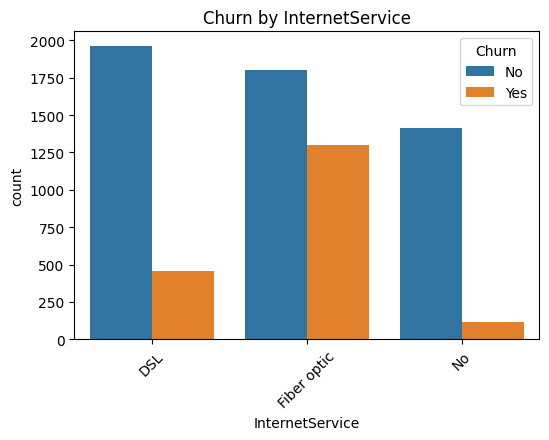

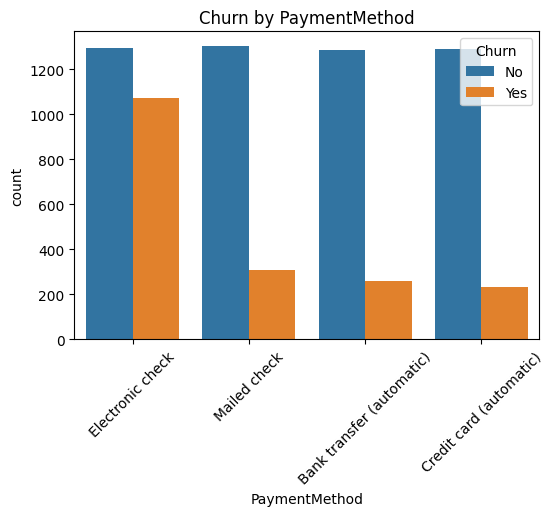

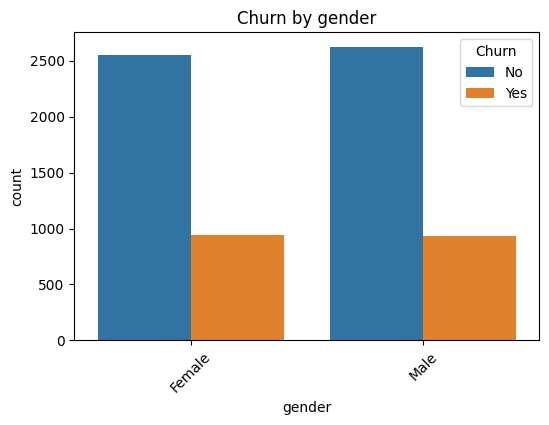

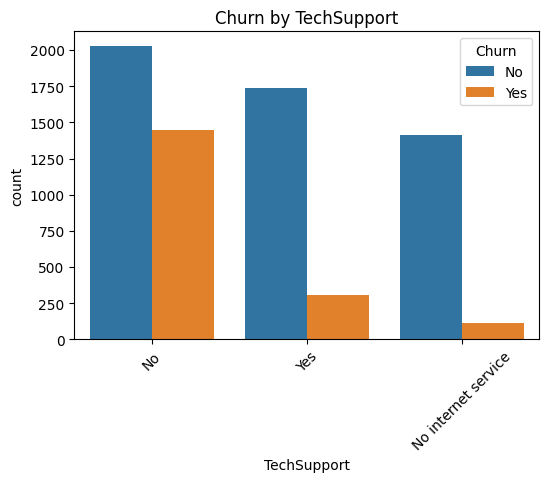

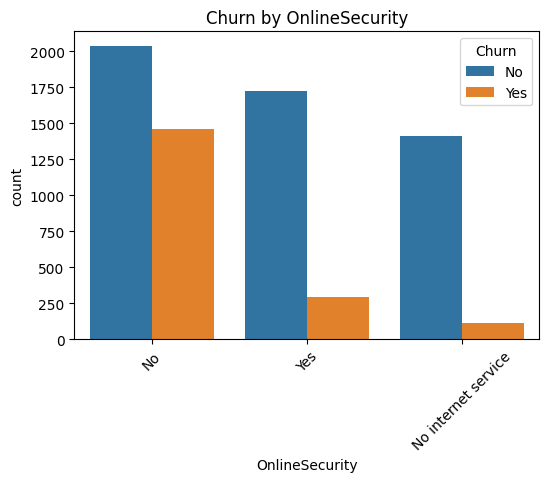

In [45]:
features = [
    "InternetService",
    "PaymentMethod",
    "gender",
    "TechSupport",
    "OnlineSecurity"
]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=feature, hue="Churn", data=df)
    plt.title(f"Churn by {feature}")
    plt.xticks(rotation=45)
    plt.show()

In [35]:
# =============================================================
# SUMMARY OF FINDINGS
# Write your observations here after running all cells above.
# This is important for your portfolio — it shows business thinking.
# =============================================================

print("""
KEY FINDINGS FROM EDA:
======================
1. Churn Rate: ~26% of customers have churned — moderately imbalanced dataset

2. Contract Type: Month-to-month customers churn at a much higher rate
   than one or two-year contract customers — strongest signal

3. Tenure: Customers who churn tend to have lower tenure
   — new customers are at higher risk

4. Monthly Charges: Churners tend to pay higher monthly charges
   — high-value customers are leaving

5. Revenue at Risk: [fill in after running Cell 11]

6. TotalCharges: Had a data quality issue (stored as string) — fixed

7. Class Imbalance: Dataset is moderately imbalanced (~74% No, ~26% Yes)
   — we need to handle this during model training
""")


KEY FINDINGS FROM EDA:
1. Churn Rate: ~26% of customers have churned — moderately imbalanced dataset

2. Contract Type: Month-to-month customers churn at a much higher rate
   than one or two-year contract customers — strongest signal

3. Tenure: Customers who churn tend to have lower tenure
   — new customers are at higher risk

4. Monthly Charges: Churners tend to pay higher monthly charges
   — high-value customers are leaving

5. Revenue at Risk: [fill in after running Cell 11]

6. TotalCharges: Had a data quality issue (stored as string) — fixed

7. Class Imbalance: Dataset is moderately imbalanced (~74% No, ~26% Yes)
   — we need to handle this during model training



C:\Users\nidhi\AppData\Local\Temp\ipykernel_16896\2993152484.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate, x=feature, y="Churn Rate (%)",
C:\Users\nidhi\AppData\Local\Temp\ipykernel_16896\2993152484.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate, x=feature, y="Churn Rate (%)",
C:\Users\nidhi\AppData\Local\Temp\ipykernel_16896\2993152484.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate, x=feature, y="Churn Rate (%)",
C:\Users\nidhi\AppData\Local\Temp\ipykernel_16896\2993152484.

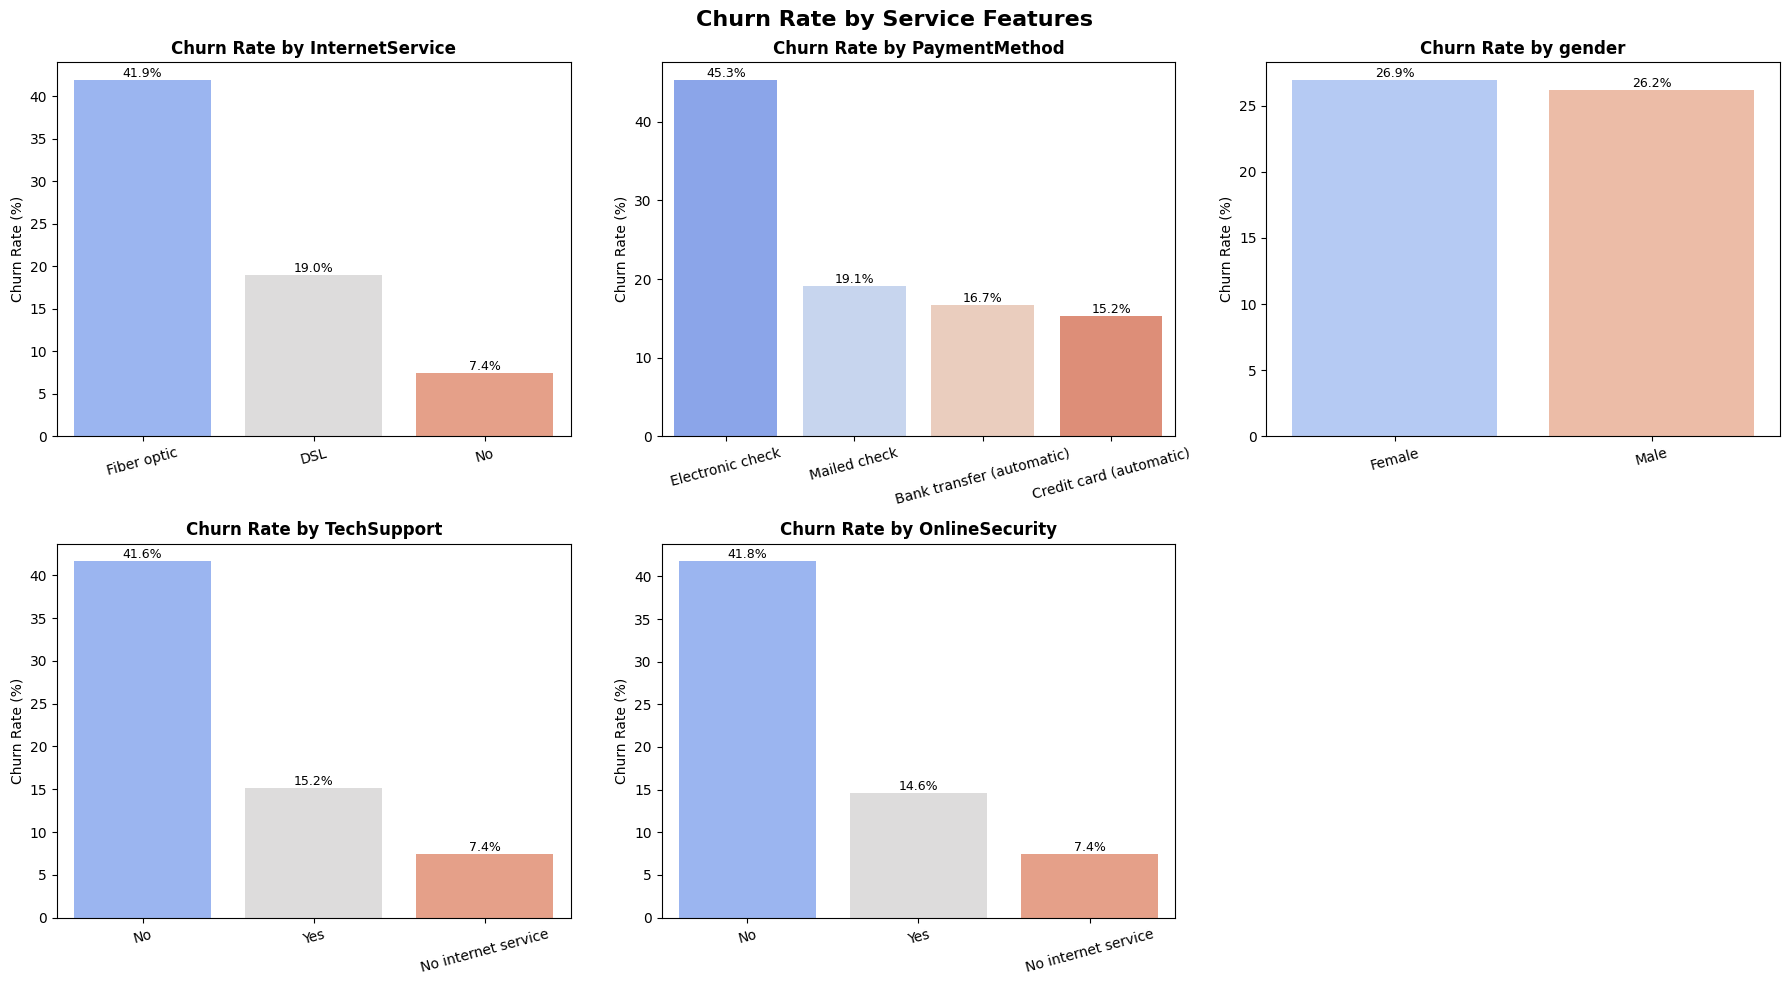

In [46]:
# =============================================================
# Churn by Internet Service, Payment Method, Gender,
# Tech Support, Online Security
#
# WHY THESE FEATURES?
# These are service-level features that might reveal which
# types of customers are most at risk — useful for targeting
# =============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# Creates a 2-row, 3-column grid of plots
# axes is a 2D array — axes[0][0] is top-left, axes[1][2] is bottom-right

features = ["InternetService", "PaymentMethod", "gender",
            "TechSupport", "OnlineSecurity"]

for i, feature in enumerate(features):
    row = i // 3      # 0 for first 3 features, 1 for last 2
    col = i % 3       # 0, 1, 2, 0, 1 cycling through columns

    # Calculate churn rate per category
    churn_rate = (df.groupby(feature)["Churn"]
                  .apply(lambda x: (x == "Yes").mean() * 100)
                  .reset_index())
    churn_rate.columns = [feature, "Churn Rate (%)"]
    churn_rate = churn_rate.sort_values("Churn Rate (%)", ascending=False)

    # Bar plot of churn rate per category
    sns.barplot(data=churn_rate, x=feature, y="Churn Rate (%)",
                ax=axes[row][col], palette="coolwarm")

    axes[row][col].set_title(f"Churn Rate by {feature}", fontsize=12, fontweight="bold")
    axes[row][col].set_xlabel("")
    axes[row][col].set_ylabel("Churn Rate (%)")
    axes[row][col].tick_params(axis='x', rotation=15)

    # Add value labels on top of each bar
    for p in axes[row][col].patches:
        axes[row][col].annotate(f"{p.get_height():.1f}%",
                                (p.get_x() + p.get_width() / 2., p.get_height()),
                                ha='center', va='bottom', fontsize=9)

# Hide the last empty subplot (we have 5 features but 6 slots)
axes[1][2].set_visible(False)

plt.suptitle("Churn Rate by Service Features", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()



In [47]:
# =============================================================
# PRINT EXACT NUMBERS — Cell 15
# Visual charts are great but exact numbers tell the full story
# =============================================================

print("=" * 50)
for feature in features:
    print(f"\nChurn Rate by {feature}:")
    rate = (df.groupby(feature)["Churn"]
            .apply(lambda x: (x == "Yes").mean() * 100)
            .round(1))
    print(rate.sort_values(ascending=False).to_string())
    print("-" * 30)


Churn Rate by InternetService:
InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
------------------------------

Churn Rate by PaymentMethod:
PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
------------------------------

Churn Rate by gender:
gender
Female    26.9
Male      26.2
------------------------------

Churn Rate by TechSupport:
TechSupport
No                     41.6
Yes                    15.2
No internet service     7.4
------------------------------

Churn Rate by OnlineSecurity:
OnlineSecurity
No                     41.8
Yes                    14.6
No internet service     7.4
------------------------------


In [48]:
# =============================================================
# TENURE SEGMENTATION — Cell 16
# Bucket tenure into groups to see churn rate more clearly
# =============================================================

bins = [0, 12, 24, 48, 72]
labels = ["0-12 months", "13-24 months", "25-48 months", "49-72 months"]

df["tenure_group"] = pd.cut(df["tenure"], bins=bins, labels=labels)

churn_by_tenure = (df.groupby("tenure_group")["Churn"]
                   .apply(lambda x: (x == "Yes").mean() * 100)
                   .round(1))

print(churn_by_tenure)

tenure_group
0-12 months     47.7
13-24 months    28.7
25-48 months    20.4
49-72 months     9.5
Name: Churn, dtype: float64
